In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

In [69]:
dtype_dict = {
    23: 'str',  
    24: 'str',  
    26: 'str',  
    27: 'str'   
}

df = pd.read_csv(file_path, dtype=dtype_dict, low_memory=False)
df = pd.read_csv(file_path)

C:\Users\Martin\AppData\Local\Temp\ipykernel_19316\1544562334.py:10: DtypeWarning: Columns (23,24,26,27) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


In [71]:
import pandas as pd

zone_ids = [193, 194, 208, 209, 210, 211, 212]
min_zones_required = 7 

df_filtered = df[df['zone_id'].isin(zone_ids)].copy()

df_filtered['timestamp'] = pd.to_datetime(df_filtered['timestamp'])

df_filtered['minute'] = df_filtered['timestamp'].dt.floor('min')

df_unique = (
    df_filtered
    .drop_duplicates(subset=['minute', 'zone_id'])
)

grouped = df_unique.groupby('minute')

complete_minutes = grouped.filter(lambda g: len(g['zone_id'].unique()) >= min_zones_required)

result = (
    complete_minutes.groupby('minute')['calculated_thermal_power']
    .sum()
    .reset_index()
    .rename(columns={'calculated_thermal_power': 'total_thermal', 'minute': 'timestamp'})
)

print(f"Found {len(result)} complete minutes")
print(result.head())

Found 3030 complete minutes
            timestamp  total_thermal
0 2018-03-23 03:27:00       1.569993
1 2018-03-23 06:30:00       2.471865
2 2018-03-24 04:27:00       0.967458
3 2018-03-24 05:55:00       1.544696
4 2018-03-24 05:59:00       1.761832


Result DataFrame columns: ['timestamp', 'total_thermal']
Calorimeter DataFrame columns: ['calorimeter_id', 'batch_timestamp', 'timestamp', 'supply_temperature', 'return_temperature', 'temperature_difference', 'mass_volume_flow', 'thermal_power', 'thermal_energy_heating', 'thermal_energy_cooling', 'error', 'interval_d', 'mode', 'mode_change', 'interval_id', 'in_cooling_interval', 'in_heating_interval', 'interval_id.1', 'interval_start', 'interval_end', 'minute']
               timestamp  total_thermal              minute  thermal_power  \
0    2018-04-19 08:32:00       0.108394 2018-04-19 08:32:00            0.3   
1    2018-04-28 17:59:00       0.886641 2018-04-28 17:59:00            0.2   
2    2019-01-01 05:31:00       0.096077 2019-01-01 05:31:00            1.5   
3    2019-01-01 09:33:00       5.180884 2019-01-01 09:33:00            5.6   
4    2019-01-02 05:31:00       0.205656 2019-01-02 05:31:00            1.9   
...                  ...            ...                 ...       

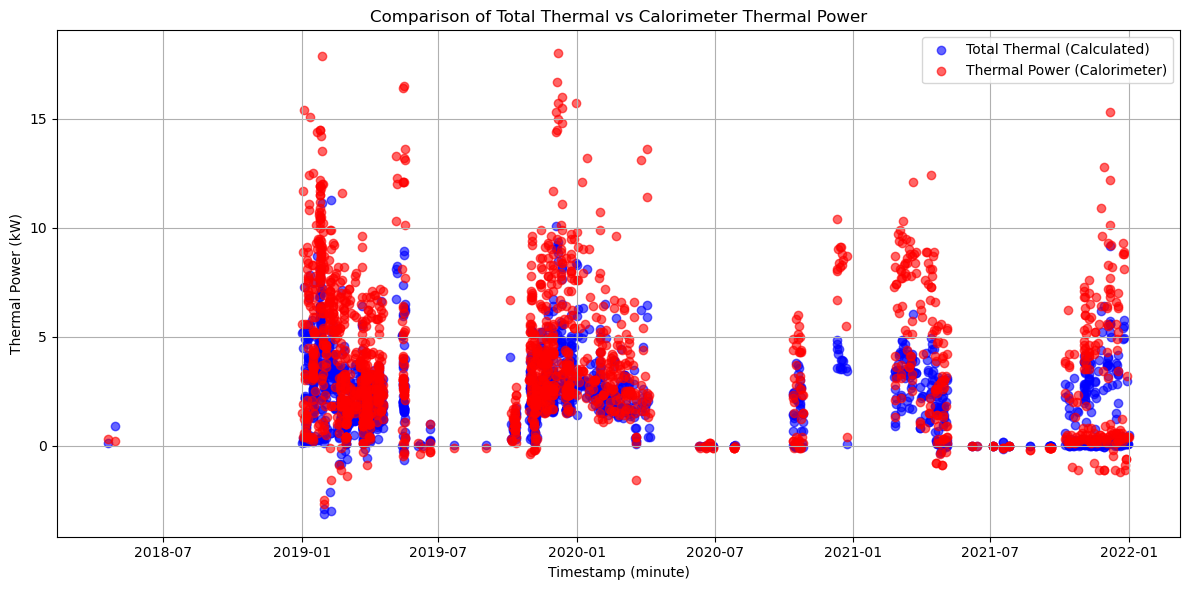

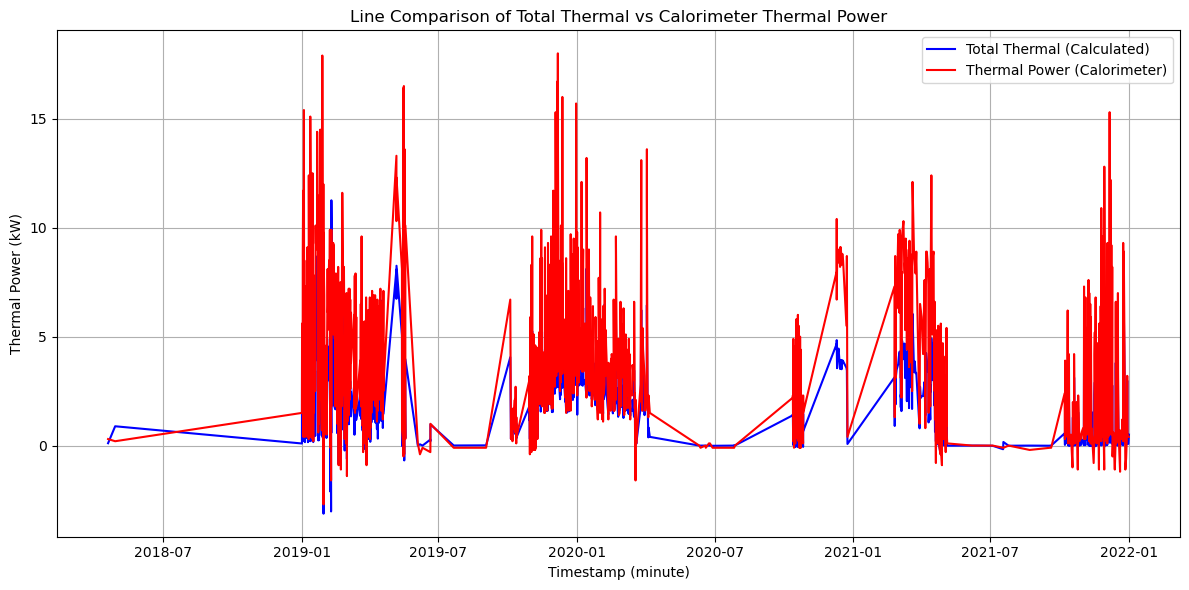

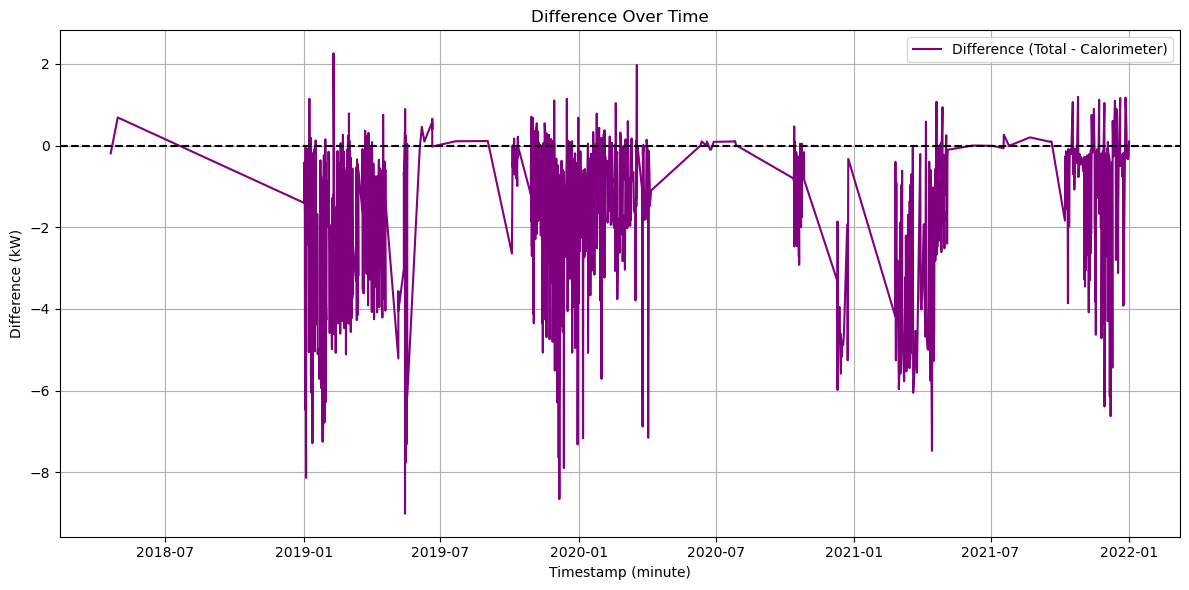

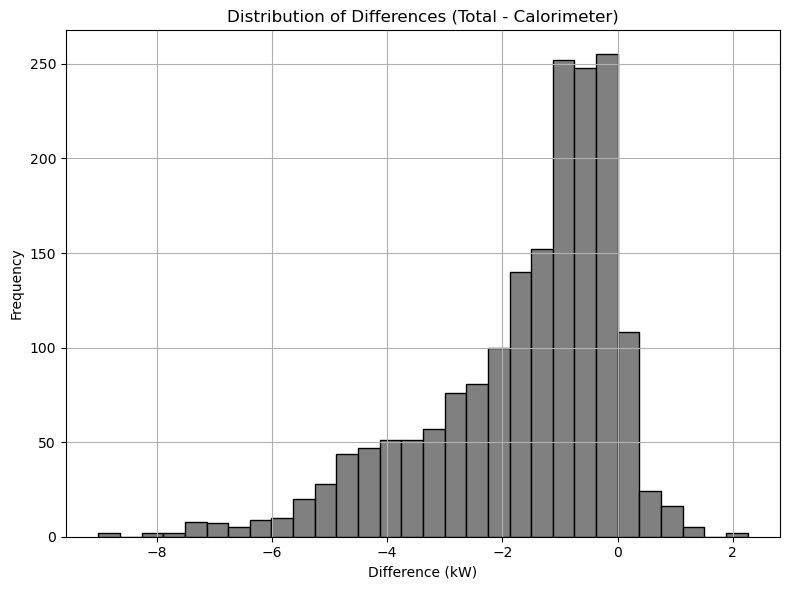

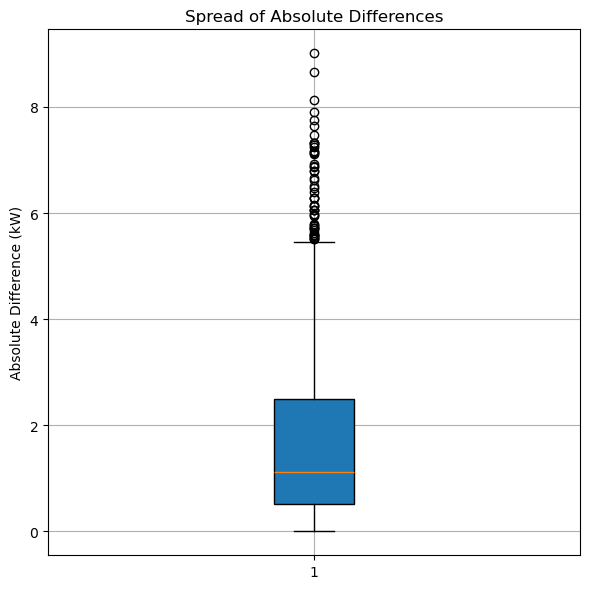

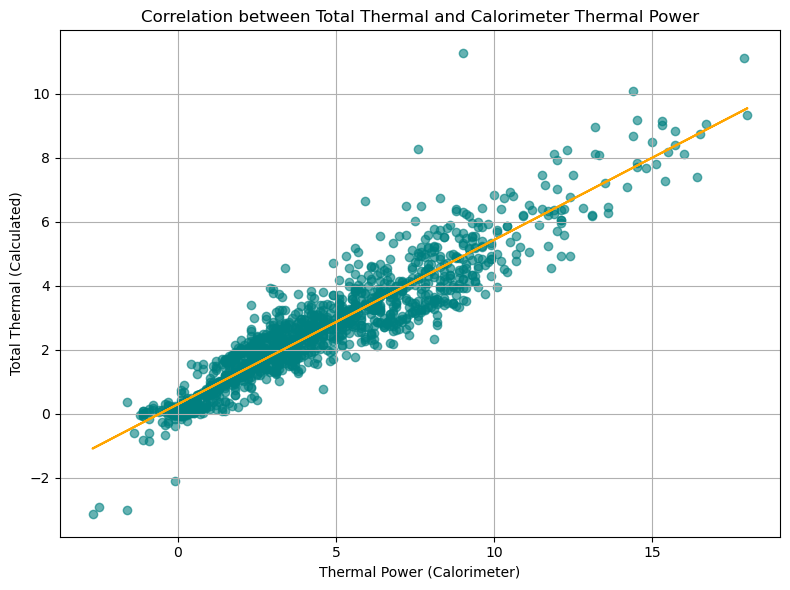

In [73]:
file_path_calorim = "../../results/cooling/23/sveGodine.csv"

data_calorim = pd.read_csv(file_path_calorim)
data_calorim['timestamp'] = pd.to_datetime(data_calorim['timestamp'])
data_calorim['minute'] = data_calorim['timestamp'].dt.floor('min')
data_calorim.columns = data_calorim.columns.str.strip()

print("Result DataFrame columns:", result.columns.tolist())
print("Calorimeter DataFrame columns:", data_calorim.columns.tolist())

comparison_df = pd.merge(
    result, 
    data_calorim[['minute', 'thermal_power']], 
    left_on='timestamp',  
    right_on='minute',    
    how='inner'
)


comparison_df['difference'] = comparison_df['total_thermal'] - comparison_df['thermal_power']
comparison_df['abs_difference'] = comparison_df['difference'].abs()

print(comparison_df)

average_abs_difference = comparison_df['abs_difference'].mean()
print("Average absolute difference:", average_abs_difference)
max_abs_difference = comparison_df['abs_difference'].max()
print("Average absolute difference:", max_abs_difference)
min_thermal = comparison_df['total_thermal'].min()
print("Min thermal: ", min_thermal)
# MAE
mae = comparison_df['abs_difference'].mean()
print("Mean Absolute Error (MAE):", mae)


comparison_df['percentage_error'] = (
    comparison_df['abs_difference'] / comparison_df['thermal_power'].replace(0, np.nan)
)
mape = comparison_df['percentage_error'].mean(skipna=True) * 100
print("Mean Absolute Percentage Error (MAPE):", mape, "%")


plt.figure(figsize=(12, 6))


plt.scatter(comparison_df['minute'], comparison_df['total_thermal'], 
            color='blue', alpha=0.6, label='Total Thermal (Calculated)')
plt.scatter(comparison_df['minute'], comparison_df['thermal_power'], 
            color='red', alpha=0.6, label='Thermal Power (Calorimeter)')


plt.xlabel("Timestamp (minute)")
plt.ylabel("Thermal Power (kW)")
plt.title("Comparison of Total Thermal vs Calorimeter Thermal Power")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(comparison_df['minute'], comparison_df['total_thermal'], 
         color='blue', label='Total Thermal (Calculated)')
plt.plot(comparison_df['minute'], comparison_df['thermal_power'], 
         color='red', label='Thermal Power (Calorimeter)')
plt.xlabel("Timestamp (minute)")
plt.ylabel("Thermal Power (kW)")
plt.title("Line Comparison of Total Thermal vs Calorimeter Thermal Power")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 6))
plt.plot(comparison_df['minute'], comparison_df['difference'], 
         color='purple', label='Difference (Total - Calorimeter)')
plt.axhline(0, color='black', linestyle='--')
plt.xlabel("Timestamp (minute)")
plt.ylabel("Difference (kW)")
plt.title("Difference Over Time")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.hist(comparison_df['difference'], bins=30, color='gray', edgecolor='black')
plt.xlabel("Difference (kW)")
plt.ylabel("Frequency")
plt.title("Distribution of Differences (Total - Calorimeter)")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
plt.boxplot(comparison_df['abs_difference'], vert=True, patch_artist=True)
plt.ylabel("Absolute Difference (kW)")
plt.title("Spread of Absolute Differences")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(comparison_df['thermal_power'], comparison_df['total_thermal'], 
            alpha=0.6, color='teal')
plt.xlabel("Thermal Power (Calorimeter)")
plt.ylabel("Total Thermal (Calculated)")
plt.title("Correlation between Total Thermal and Calorimeter Thermal Power")

import numpy as np
m, b = np.polyfit(comparison_df['thermal_power'], comparison_df['total_thermal'], 1)
plt.plot(comparison_df['thermal_power'], m*comparison_df['thermal_power'] + b, color='orange')

plt.grid(True)
plt.tight_layout()
plt.show()

In [83]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

X = comparison_df[['total_thermal']]
y = comparison_df['thermal_power']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nEvaluacija modela:")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.4f}")
print(f"Koeficijenti: {model.coef_}")
print(f"Intercept: {model.intercept_:.4f}")


Evaluacija modela:
Mean Squared Error: 1.27
R-squared: 0.8803
Koeficijenti: [1.70136415]
Intercept: -0.0073


In [87]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)  # 5-fold CV

cv_scores = cross_val_score(model, X, y, cv=kfold, scoring='r2')
mse_scores = -cross_val_score(model, X, y, cv=kfold, scoring='neg_mean_squared_error')

print("Cross-Validation Results:")
print(f"R² Scores for each fold: {cv_scores}")
print(f"Mean R²: {np.mean(cv_scores):.2f} (±{np.std(cv_scores):.2f})")
print(f"MSE Scores for each fold: {mse_scores}")
print(f"Mean MSE: {np.mean(mse_scores):.2f} (±{np.std(mse_scores):.2f})")


Cross-Validation Results:
R² Scores for each fold: [0.88029694 0.88860352 0.86993473 0.87347981 0.88398377]
Mean R²: 0.88 (±0.01)
MSE Scores for each fold: [1.27226231 1.27947714 1.35508132 1.08018251 1.05124629]
Mean MSE: 1.21 (±0.12)


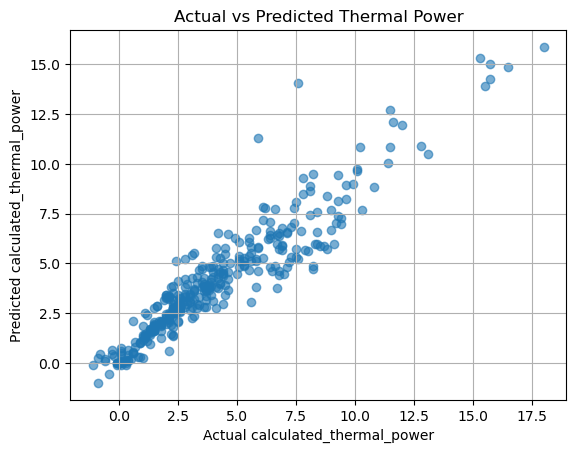

In [89]:
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual calculated_thermal_power")
plt.ylabel("Predicted calculated_thermal_power")
plt.title("Actual vs Predicted Thermal Power")
plt.grid(True)
plt.show()


In [91]:
from joblib import dump
dump(model, 'random_forest_model.joblib')

['random_forest_model.joblib']